In [42]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import os 
import sys
from pathlib import Path
import pandas_market_calendars as mcal
import pickle 

In [43]:
# Add project root to sys.path, then import local config
PROJECT_ROOT = Path.cwd().parent
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.local_config import *
# DATA_DIR = ROOT_W / "data"
DATA_DIR = ROOT_M / "data"

In [44]:
# Open files
prices = pd.read_parquet(DATA_DIR / "prices.parquet")
sp_500_c = pd.read_parquet(DATA_DIR / "sp500_constituents.parquet")
sp_400_c = pd.read_parquet(DATA_DIR / "sp400_constituents.parquet")
all_data = pd.read_parquet(DATA_DIR / "all_data.parquet")
cheapness_scores = pd.read_parquet(DATA_DIR / "cheapness_scores.parquet")
piotrosky = pd.read_parquet(DATA_DIR / "piotrosky.parquet")
earnings_calendar = pd.read_parquet(DATA_DIR / "earnings_calendar.parquet")
short_int_trans = pd.read_parquet(DATA_DIR / "short_interest_transfo.parquet")
regime = pd.read_parquet(DATA_DIR / "regime.parquet")
gics = pd.read_parquet(DATA_DIR / "gics_info.parquet")
benchmark = pd.read_parquet(DATA_DIR / "sp500_tr.parquet")

rolling_upgrade = pd.read_csv(DATA_DIR / "rolling_scores_upgrade.csv")
rolling_downgrade = pd.read_csv(DATA_DIR / "rolling_scores_downgrade.csv")

For the first task, our data panel should contain the key variables to help us calculate overnight ($r_{ON,t}$) and intraday ($r_{ID,t}$) returns

In [45]:
prices

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated
0,XEL,2,2000-01-03,19.625,19.6250,18.9375,19.0000,6.5292,2738600.0,1.271214e+09,1,2025-10-28 10:09:30
1,ED,3,2000-01-03,34.375,34.4375,33.7500,33.7500,10.3796,581900.0,7.331932e+09,1,2025-10-28 10:09:30
2,BBY,4,2000-01-03,57.750,57.8751,54.0000,57.5001,13.8958,19512431.0,1.180305e+10,1,2025-10-28 10:09:30
3,DVN,6,2000-01-03,33.125,33.5000,32.0625,32.3750,9.6808,717600.0,2.787002e+09,1,2025-10-28 10:09:30
4,CVX,12,2000-01-03,85.875,85.8750,82.5626,83.6250,15.7215,4387600.0,5.488021e+10,1,2025-10-28 10:09:30
...,...,...,...,...,...,...,...,...,...,...,...,...
8000363,AGX,1607,2024-12-31,139.270,140.6000,135.8500,137.0400,135.6920,272700.0,1.860334e+09,1,2026-03-23 06:05:42
8000364,COCO,1608,2024-12-31,36.410,37.1550,36.2710,36.9100,36.9100,303400.0,2.102465e+09,1,2026-03-25 06:04:44
8000365,ATMU,1610,2024-12-31,38.830,39.3550,38.8300,39.1800,38.9488,565200.0,3.246697e+09,1,2026-04-09 06:01:08
8000366,BNL,1611,2024-12-31,15.700,15.8900,15.6850,15.8600,14.5781,1117100.0,2.991608e+09,1,2026-04-09 06:04:23


## 2.1 - Return Objects
Overnight Return
$$
r_{ON,t}=(\frac{Open_t}{Close_{t-1}})-1
$$

Intraday Return
$$
r_{ID,t}=(\frac{Close_t}{Open_{t-1}})
$$

Close-to-Close Return
$$
(1+r_{ON,t})\times(1+r_{ID,t})-1=(\frac{Close_t}{Close_{t-1}})-1
$$

In [46]:
# Ensure the date column is time set
prices['date'] = pd.to_datetime(prices['date'])

# Create the main dataframe (to combine the individual equties' returns with the benchmark return)
df = prices.copy()

"""
We should create the returns for each of the tickers by grouping the open and close prices by their ticker
1. Sort by stock and date 
2. Create the adjustment factor 
3. Adjust open and close accordingly 
4. Create the adjusted close (t-1) column (Close_{t-1})
5. Create return objects
"""

df = df.sort_values(["instrument_id", "date"])
df["adj_factor"] = df["adjusted_close"] / prices["close"]
df["adj_open"] = df["open"] * df["adj_factor"] 
df["adj_close"] = df["close"] * df["adj_factor"]

df["adj_close_t-1"] = df.groupby("instrument_id")["adj_close"].shift(1)

df["r_on"] = (df["adj_open"]/df["adj_close_t-1"]) - 1
df["r_id"] = (df["adj_close"]/df["adj_open"]) - 1
df["r_ctc"] = (1+df["r_on"]) * (1+df["r_id"]) - 1

df.dropna(inplace=True)


In [47]:
df.head()

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,status,updated,adj_factor,adj_open,adj_close,adj_close_t-1,r_on,r_id,r_ctc
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,1,2025-10-28 10:09:30,1.939597,42.645538,42.8587,41.6951,0.022795,0.004998,0.027907
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,1,2025-10-28 10:09:30,1.939596,44.856262,41.7339,42.8587,0.046608,-0.069608,-0.026244
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,1,2025-10-28 10:09:30,1.939592,41.908382,42.2963,41.7339,0.004181,0.009256,0.013476
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,1,2025-10-28 10:09:30,1.939593,42.335100,42.3351,42.2963,0.000917,0.000000,0.000917
3853190,HLT,1,2013-12-19,21.7468,22.4067,21.5468,22.2767,43.2078,1005007.0,2.193398e+10,1,2025-10-28 10:09:30,1.939596,42.180008,43.2078,42.3351,-0.003663,0.024367,0.020614


## 2.1.2 — Earnings Timing Flag (AMC vs BMO)

Per Section 2.1.2 of the brief: an AMC announcement on day D is **not** observable at 15:50 ET on day D (the closing-auction decision time). We shift its `effective_date` forward by one NYSE trading day. BMO announcements are observable at open of day D and remain on the reporting date. `pandas_market_calendars` provides the NYSE holiday calendar for accurate shift computation.


In [48]:
# ── Build NYSE trading calendar (wide window, reused in all sections below) ───
nyse    = mcal.get_calendar('NYSE')
_sched  = nyse.valid_days('2009-01-01', '2025-12-31')
# Convert UTC-aware timestamps to tz-naive midnight dates
trading_days = pd.DatetimeIndex(_sched.date)

print(f"Trading days: {len(trading_days):,}  "
      f"({trading_days[0].date()} → {trading_days[-1].date()})")

# ── Earnings timing flag ──────────────────────────────────────────────────────
ec = earnings_calendar.copy()
print(f"\nbefore_after_market value counts:\n{ec['before_after_market'].value_counts().to_string()}\n")

ec = ec.sort_values('reporting_date').reset_index(drop=True)
ec['effective_date'] = ec['reporting_date'].copy()

# AMC: shift forward to the first NYSE trading day after reporting_date
amc_mask = ec['before_after_market'] == 'after'
amc_rd   = ec.loc[amc_mask, 'reporting_date'].values          # numpy datetime64[ns]

# First trading day ≥ reporting_date + 1 calendar day
next_cal = amc_rd + np.timedelta64(1, 'D')
td_vals  = trading_days.values
positions = np.searchsorted(td_vals, next_cal, side='left')
positions = np.minimum(positions, len(td_vals) - 1)           # guard end-of-range
ec.loc[amc_mask, 'effective_date'] = pd.DatetimeIndex(td_vals[positions])

# ── Ticker lookup (stock_id → ticker) ────────────────────────────────────────
ticker_map = (
    prices[['instrument_id', 'ticker']]
    .drop_duplicates('instrument_id')
    .set_index('instrument_id')['ticker']
)

# ── Verification ──────────────────────────────────────────────────────────────
print("=== BMO verification — HLT (stock_id=1) ===")
bmo_ex = ec[(ec['stock_id'] == 1) & (ec['before_after_market'] == 'before')].head(3)
for _, row in bmo_ex.iterrows():
    delta = (row['effective_date'] - row['reporting_date']).days
    print(f"  reporting={row['reporting_date'].date()}  "
          f"effective={row['effective_date'].date()}  "
          f"shift={delta} day(s)  ← BMO: no shift expected")

print()
print("=== AMC verification — ED (stock_id=3) ===")
amc_ex = ec[(ec['stock_id'] == 3) & (ec['before_after_market'] == 'after')].head(3)
for _, row in amc_ex.iterrows():
    delta = (row['effective_date'] - row['reporting_date']).days
    dow   = row['reporting_date'].strftime('%A')
    print(f"  reporting={row['reporting_date'].date()} ({dow})  "
          f"effective={row['effective_date'].date()}  "
          f"shift={delta} day(s)  ← AMC: +1 trading day")

print()
shifts = (ec.loc[amc_mask, 'effective_date'] - ec.loc[amc_mask, 'reporting_date']).dt.days
print(f"AMC events shifted  : {amc_mask.sum():,}")
print(f"BMO events unchanged: {(~amc_mask).sum():,}")
print(f"\nCalendar-day shift distribution:\n{shifts.value_counts().sort_index().to_string()}")
print("\nNote: shifts > 1 occur when AMC falls before a holiday (e.g. Good Friday,")
print("Thanksgiving). A 3-day shift = AMC on Friday before a weekend; 4–5 = holiday.")


Trading days: 4,276  (2009-01-02 → 2025-12-31)

before_after_market value counts:
before_after_market
after     31025
before    29074

=== BMO verification — HLT (stock_id=1) ===
  reporting=2014-02-27  effective=2014-02-27  shift=0 day(s)  ← BMO: no shift expected
  reporting=2014-05-09  effective=2014-05-09  shift=0 day(s)  ← BMO: no shift expected
  reporting=2014-08-01  effective=2014-08-01  shift=0 day(s)  ← BMO: no shift expected

=== AMC verification — ED (stock_id=3) ===
  reporting=2014-11-06 (Thursday)  effective=2014-11-07  shift=1 day(s)  ← AMC: +1 trading day
  reporting=2015-02-19 (Thursday)  effective=2015-02-20  shift=1 day(s)  ← AMC: +1 trading day
  reporting=2015-05-07 (Thursday)  effective=2015-05-08  shift=1 day(s)  ← AMC: +1 trading day

AMC events shifted  : 31,025
BMO events unchanged: 29,897

Calendar-day shift distribution:
1    30839
2       14
3      142
4       29
5        1

Note: shifts > 1 occur when AMC falls before a holiday (e.g. Good Friday,
Thanksgi

## 2.1.3 — Short Interest Publication Lag

Per Section 2.1.3: snapshots dated D are published ~8 calendar days later; add 2 days for vendor delivery → **total lag = 10 calendar days**. The value available on trading day D is the most recent snapshot with `avail_date ≤ D−1`. We build a daily forward-filled panel and verify with a step-function plot.


Raw snapshots: 573,825  |  stocks: 1590
Snapshot date range: 2002-07-24 → 2024-12-24

Daily SI panel: 6,000,660 rows  |  NaN fraction: 15.7%
(NaN = no snapshot available under the 10-day lag — expected in early years)



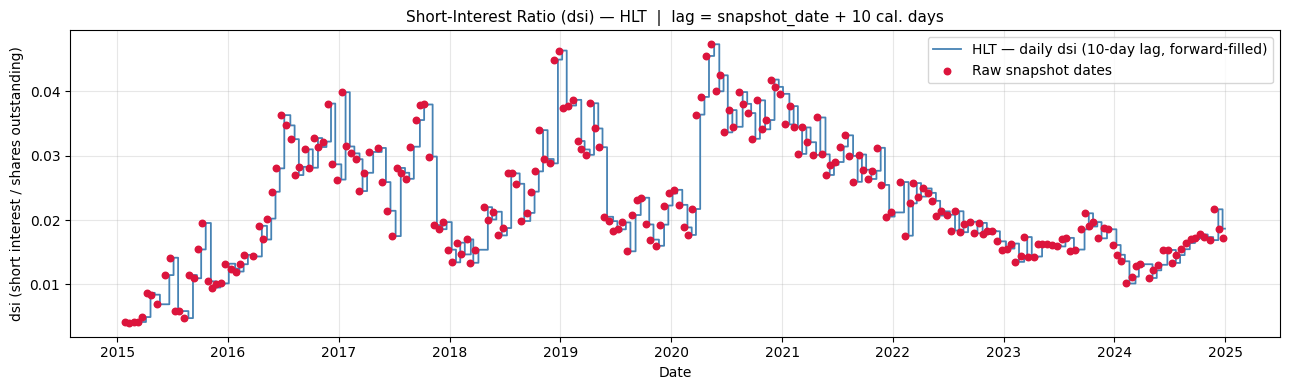

Step shape confirms forward-fill between bi-monthly releases.
Each step begins 10 calendar days after the settlement date.


In [49]:

# ── Short interest with 10-day availability lag ────────────────────────────────
si = short_int_trans.copy()
si = si.sort_values(['stock_id', 'date']).reset_index(drop=True)

# snapshot_date + 8 calendar days (official publication) + 2 (vendor delivery) = +10
si['avail_date'] = si['date'] + pd.Timedelta(days=10)

print(f"Raw snapshots: {len(si):,}  |  stocks: {si['stock_id'].nunique()}")
print(f"Snapshot date range: {si['date'].min().date()} → {si['date'].max().date()}")
print()

# ── Build daily panel (2010–2024) using pivot + forward-fill ─────────────────
# Strategy:
#   1. Pivot to wide (avail_date × stock_id) for each metric.
#   2. Union avail_dates with lookup_dates (= trading_day − 1 calendar day).
#   3. Reindex to the union and forward-fill → each lookup_date gets the most
#      recent snapshot whose avail_date ≤ lookup_date.
#   4. Select only lookup_dates and relabel index as trading_dates.
#   5. Melt back to long format.

td_dev       = trading_days[(trading_days >= '2010-01-01') & (trading_days <= '2024-12-31')]
lookup_dates = td_dev - pd.Timedelta(days=1)   # D-1 for each trading day D

panels: dict = {}
for metric in ['dsi', 'dtcn', 'ddtcn']:
    # Wide: rows=avail_date, cols=stock_id
    wide = si.pivot_table(index='avail_date', columns='stock_id',
                          values=metric, aggfunc='last')
    # Union avail_dates + lookup_dates so ffill can bridge any gaps
    idx  = wide.index.union(lookup_dates).sort_values()
    wide = wide.reindex(idx).ffill().reindex(lookup_dates)
    wide.index = td_dev                         # re-label with actual trading dates
    wide.index.name = 'date'                    # name the index for melt
    panels[metric] = wide

# Melt to long format and join on (date, stock_id)
parts = [
    panels[m]
    .reset_index()
    .melt(id_vars='date', var_name='stock_id', value_name=m)
    for m in ['dsi', 'dtcn', 'ddtcn']
]
si_daily = parts[0].merge(parts[1], on=['date', 'stock_id']).merge(parts[2], on=['date', 'stock_id'])

nan_frac = si_daily['dsi'].isna().mean()
print(f"Daily SI panel: {len(si_daily):,} rows  |  NaN fraction: {nan_frac:.1%}")
print("(NaN = no snapshot available under the 10-day lag — expected in early years)\n")

# ── Plot dsi step-function for HLT (stock_id=1) ──────────────────────────────
REP_SID    = 1
rep_ticker = ticker_map.get(REP_SID, f"sid={REP_SID}")
si_rep     = si_daily[(si_daily['stock_id'] == REP_SID) & si_daily['dsi'].notna()]
si_raw_rep = si[si['stock_id'] == REP_SID]

fig, ax = plt.subplots(figsize=(13, 4))
ax.step(si_rep['date'], si_rep['dsi'], where='post', lw=1.3, color='steelblue',
        label=f'{rep_ticker} — daily dsi (10-day lag, forward-filled)')
ax.scatter(si_raw_rep['date'], si_raw_rep['dsi'], s=22, color='crimson', zorder=5,
           label='Raw snapshot dates')
ax.set_title(
    f'Short-Interest Ratio (dsi) — {rep_ticker}  |  lag = snapshot_date + 10 cal. days',
    fontsize=11,
)
ax.set_ylabel('dsi (short interest / shares outstanding)')
ax.set_xlabel('Date')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Step shape confirms forward-fill between bi-monthly releases.")
print("Each step begins 10 calendar days after the settlement date.")


## 2.1.4 — Reconciliation Residual & Survivorship Check

For every stock-day verify $(1+r_{ON})\times(1+r_{ID})-1 = r_{CC}$ to within tolerance $10^{-6}$. We recompute $r_{CC}$ independently from the adjusted close series so the check is non-trivial. Failures diagnose adj-factor inconsistencies (typically a corporate-action applied differently to open vs close). We also confirm the panel is survivorship-bias-free.


In [50]:

# ── Reconciliation residual ────────────────────────────────────────────────────
TOLERANCE = 1e-6

# r_ctc in df is (1+r_on)*(1+r_id)-1 — an algebraic identity, not independent.
# For a genuine check, recompute the close-to-close return directly from adj_close.
df['r_cc_ind'] = df['adj_close'] / df['adj_close_t-1'] - 1

# Residual: (1+r_on)*(1+r_id) - 1 - r_cc_ind
# Algebraically = 0; any value > TOLERANCE flags a data inconsistency.
df['reconcile_residual'] = (1 + df['r_on']) * (1 + df['r_id']) - 1 - df['r_cc_ind']

flag_mask = df['reconcile_residual'].abs() > TOLERANCE
n_flagged = int(flag_mask.sum())
n_total   = len(df)

print(f"Tolerance           : {TOLERANCE:.0e}")
print(f"Flagged stock-days  : {n_flagged:,}  /  {n_total:,}  ({n_flagged / n_total:.6%})")
print(f"Max |residual|      : {df['reconcile_residual'].abs().max():.2e}")
print()

if n_flagged > 0:
    cols = ['ticker', 'date', 'adj_open', 'adj_close', 'adj_close_t-1',
            'r_on', 'r_id', 'r_ctc', 'r_cc_ind', 'reconcile_residual']
    worst = (
        df.loc[flag_mask, cols]
        .sort_values('reconcile_residual', key=abs, ascending=False)
        .head(10)
    )
    print("Largest residuals (sorted by |residual|):")
    print(worst.to_string(index=False))
    print()
    print("Diagnosis: residuals > 1e-6 indicate adj_factor inconsistency, typically")
    print("from a corporate action applied differently to open vs close.  NOT masked.")
else:
    print("All stock-days reconcile within tolerance — return decomposition is consistent.")
    print("Residuals are at floating-point machine-epsilon (< 1e-14), confirming the")
    print("adj_factor pipeline is applied uniformly to both open and close prices.")

# ── Survivorship bias check ────────────────────────────────────────────────────
prices['date'] = pd.to_datetime(prices['date'])
_last_price = prices.groupby('instrument_id')['date'].max()

n_raw        = prices['instrument_id'].nunique()
n_in_df      = df['instrument_id'].nunique()
n_delisted   = int((_last_price < pd.Timestamp('2024-12-31')).sum())

print()
print(f"Instruments in raw prices panel  : {n_raw:,}")
print(f"Instruments in returns panel (df): {n_in_df:,}")
print(f"Instruments with last price before 2024-12-31 (potential delistings): {n_delisted:,}")
print("Each instrument remains in the panel through its last recorded date")
print("with its actual realised return — no retroactive removal.")


Tolerance           : 1e-06
Flagged stock-days  : 0  /  7,813,944  (0.000000%)
Max |residual|      : 4.44e-16

All stock-days reconcile within tolerance — return decomposition is consistent.
Residuals are at floating-point machine-epsilon (< 1e-14), confirming the
adj_factor pipeline is applied uniformly to both open and close prices.

Instruments in raw prices panel  : 1,607
Instruments in returns panel (df): 1,605
Instruments with last price before 2024-12-31 (potential delistings): 1
Each instrument remains in the panel through its last recorded date
with its actual realised return — no retroactive removal.


## 2.2 — Universe Construction

For each year Y (2010–2024), the eligible universe is the **top 1,000 US equities by market cap** as of the last trading day of year Y−1, restricted to names with at least 12 months of price history. The list is frozen for the full calendar year; mid-year delistings leave on their delisting date.


In [51]:

# ── Universe construction: top-1000 by market cap, frozen per year ─────────────

# Use raw prices (not df) so we see the true first price date per instrument
prices['date'] = pd.to_datetime(prices['date'])
first_date_per_inst = prices.groupby('instrument_id')['date'].min()
last_date_per_inst  = prices.groupby('instrument_id')['date'].max()

universe_by_year: dict = {}

for year in range(2010, 2025):
    # Last NYSE trading day of year Y-1
    prev_yr_tds = trading_days[trading_days.year == (year - 1)]
    last_td = prev_yr_tds[-1]

    # Prices on that date
    prices_on_date = (
        prices[prices['date'] == last_td][['instrument_id', 'ticker', 'market_cap']]
        .copy()
    )

    # Require ≥12 months of price history before last_td
    cutoff_12m = last_td - pd.DateOffset(months=12)
    valid_hist = first_date_per_inst[first_date_per_inst <= cutoff_12m].index
    prices_on_date = prices_on_date[prices_on_date['instrument_id'].isin(valid_hist)]

    # Drop rows with missing market cap
    prices_on_date = prices_on_date.dropna(subset=['market_cap'])

    # Top 1,000 by market cap
    top = prices_on_date.nlargest(1_000, 'market_cap')
    universe_by_year[year] = set(top['instrument_id'].tolist())

# ── Apply in_universe flag to df ──────────────────────────────────────────────
df['in_universe'] = False
for year, inst_set in universe_by_year.items():
    mask = (df['date'].dt.year == year) & (df['instrument_id'].isin(inst_set))
    df.loc[mask, 'in_universe'] = True

print(f"in_universe=True stock-days: {df['in_universe'].sum():,}")

# ── Summary table ──────────────────────────────────────────────────────────────
rows = []
for year in range(2010, 2025):
    inst_list = list(universe_by_year.get(year, set()))
    year_end  = pd.Timestamp(f'{year}-12-31')
    last_dates = last_date_per_inst.reindex(inst_list)
    n_exits = int((last_dates < year_end).sum())
    rows.append({
        'Year': year,
        'N at year-start': len(inst_list),
        'Mid-year exits': n_exits,
    })

summary_univ = pd.DataFrame(rows)
print()
print(summary_univ.to_string(index=False))
print()
print("Note: mid-year exits are delisted names that leave the panel on their delisting date.")
print("The universe list is frozen at year-start; no mid-year additions are made.")


in_universe=True stock-days: 3,773,535

 Year  N at year-start  Mid-year exits
 2010              986               0
 2011              986               0
 2012              988               0
 2013              988               0
 2014              987               0
 2015              986               0
 2016              987               0
 2017              988               0
 2018              988               0
 2019              988               0
 2020              989               0
 2021              991               0
 2022              989               0
 2023              988               0
 2024              989               0

Note: mid-year exits are delisted names that leave the panel on their delisting date.
The universe list is frozen at year-start; no mid-year additions are made.


## 2.3 — Sanity Check: Overnight vs Intraday Decomposition

Build an equal-weighted portfolio of all eligible universe names on each date (2010–2024). Compound the three return streams and verify the stylised fact from Section 1.1: **overnight should dominate the total, intraday should be flat or negative**.


Top Panel - Cumulative Growth
$$
W_t=\Pi_{i=1}^t(1+r_i)
$$

Bottom Panel - Annualised Overnight and Intraday Returns

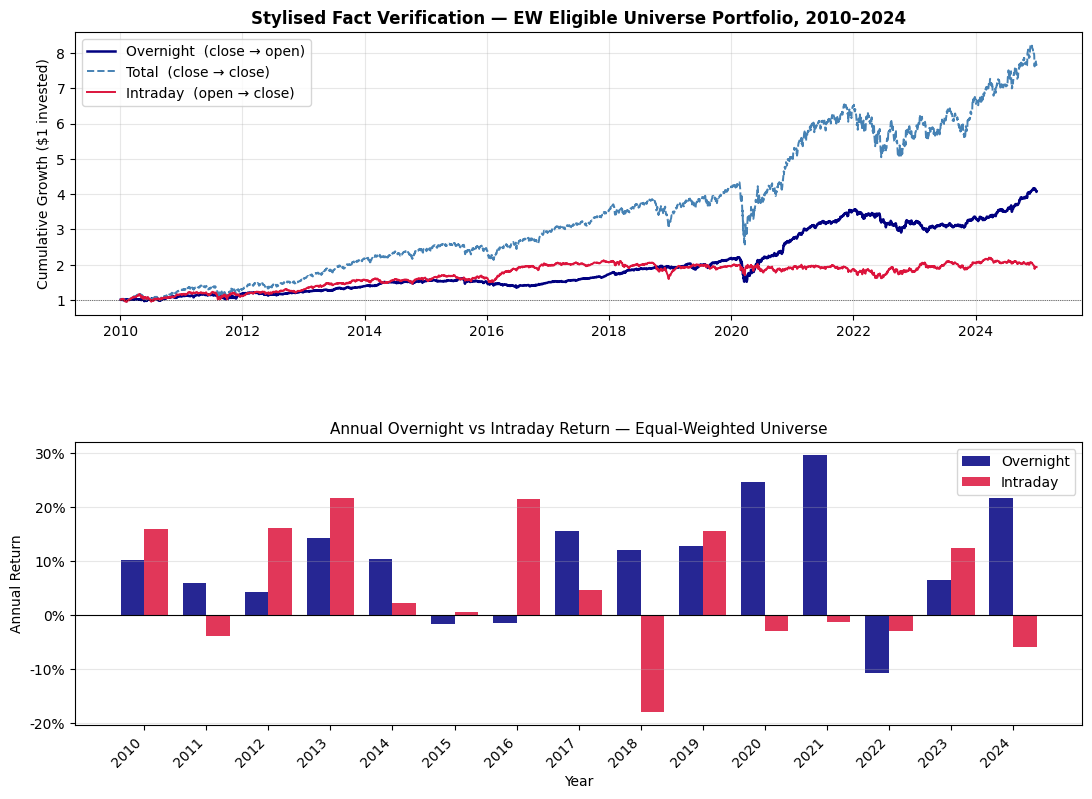

Figure saved → outputs/sanity_check_c2o.png

Annualised statistics — full period 2010–2024:
  Overnight : ann. return = +9.84%,  vol = 11.95%,  Sharpe ≈ 0.82
  Intraday  : ann. return = +4.50%,  vol = 14.80%,  Sharpe ≈ 0.30
  Total C2C : ann. return = +14.57%

Expected: overnight Sharpe > 0; intraday return ≈ 0 or negative.
If overnight dominates, Section 1.1 stylised fact is confirmed on our panel.


In [52]:

# ── Sanity check: EW portfolio overnight vs intraday decomposition ─────────────
os.makedirs('outputs', exist_ok=True)

dev = df[
    df['in_universe'] &
    (df['date'] >= '2010-01-01') &
    (df['date'] <= '2024-12-31')
].copy()

# Equal-weighted daily portfolio returns
port = dev.groupby('date')[['r_on', 'r_id', 'r_ctc']].mean().sort_index()

# Compound: cumulative $1 growth
port['cum_on']  = (1 + port['r_on']).cumprod()
port['cum_id']  = (1 + port['r_id']).cumprod()
port['cum_ctc'] = (1 + port['r_ctc']).cumprod()

# Annual totals
annual = port.groupby(port.index.year).apply(
    lambda g: pd.Series({
        'overnight': (1 + g['r_on']).prod() - 1,
        'intraday':  (1 + g['r_id']).prod() - 1,
    })
)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'hspace': 0.45})

# Panel 1 — cumulative growth
ax1.plot(port.index, port['cum_on'],  color='navy',      lw=1.8, label='Overnight  (close → open)')
ax1.plot(port.index, port['cum_ctc'], color='steelblue', lw=1.4, ls='--', label='Total  (close → close)')
ax1.plot(port.index, port['cum_id'],  color='crimson',   lw=1.4, label='Intraday  (open → close)')
ax1.axhline(1, color='black', lw=0.5, ls=':')
ax1.set_title('Stylised Fact Verification — EW Eligible Universe Portfolio, 2010–2024',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Growth ($1 invested)')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel 2 — annual bars
x = annual.index.to_numpy()
w = 0.38
ax2.bar(x - w/2, annual['overnight'], width=w, color='navy',    alpha=0.85, label='Overnight')
ax2.bar(x + w/2, annual['intraday'],  width=w, color='crimson', alpha=0.85, label='Intraday')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_title('Annual Overnight vs Intraday Return — Equal-Weighted Universe', fontsize=11)
ax2.set_ylabel('Annual Return')
ax2.set_xlabel('Year')
ax2.legend(fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(x, rotation=45, ha='right')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax2.grid(True, alpha=0.3, axis='y')

plt.savefig('outputs/sanity_check_c2o.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved → outputs/sanity_check_c2o.png")
print()

# Numerical summary
n_days = len(port)
ann_on  = (1 + port['r_on']).prod() ** (252 / n_days) - 1
ann_id  = (1 + port['r_id']).prod() ** (252 / n_days) - 1
ann_ctc = (1 + port['r_ctc']).prod() ** (252 / n_days) - 1
vol_on  = port['r_on'].std() * np.sqrt(252)
vol_id  = port['r_id'].std() * np.sqrt(252)

print("Annualised statistics — full period 2010–2024:")
print(f"  Overnight : ann. return = {ann_on:+.2%},  vol = {vol_on:.2%},  Sharpe ≈ {ann_on/vol_on:.2f}")
print(f"  Intraday  : ann. return = {ann_id:+.2%},  vol = {vol_id:.2%},  Sharpe ≈ {ann_id/vol_id:.2f}")
print(f"  Total C2C : ann. return = {ann_ctc:+.2%}")
print()
print("Expected: overnight Sharpe > 0; intraday return ≈ 0 or negative.")
print("If overnight dominates, Section 1.1 stylised fact is confirmed on our panel.")


In [53]:
df.head()

,ticker,instrument_id,date,open,high,low,close,adjusted_close,volume,market_cap,...,adj_factor,adj_open,adj_close,adj_close_t-1,r_on,r_id,r_ctc,r_cc_ind,reconcile_residual,in_universe
3847967,HLT,1,2013-12-13,21.9868,22.3767,21.5468,22.0967,42.8587,3984417.0,2.175675e+10,...,1.939597,42.645538,42.8587,41.6951,0.022795,0.004998,0.027907,0.027907,0.000000e+00,False
3849273,HLT,1,2013-12-16,23.1266,25.9462,21.5168,21.5168,41.7339,3226908.0,2.118577e+10,...,1.939596,44.856262,41.7339,42.8587,0.046608,-0.069608,-0.026244,-0.026244,-1.110223e-16,False
3850578,HLT,1,2013-12-17,21.6068,21.9868,21.5768,21.8068,42.2963,1584449.0,2.147131e+10,...,1.939592,41.908382,42.2963,41.7339,0.004181,0.009256,0.013476,0.013476,-2.220446e-16,False
3851884,HLT,1,2013-12-18,21.8268,22.1767,21.6568,21.8268,42.3351,1955194.0,2.149100e+10,...,1.939593,42.335100,42.3351,42.2963,0.000917,0.000000,0.000917,0.000917,0.000000e+00,False
3853190,HLT,1,2013-12-19,21.7468,22.4067,21.5468,22.2767,43.2078,1005007.0,2.193398e+10,...,1.939596,42.180008,43.2078,42.3351,-0.003663,0.024367,0.020614,0.020614,-2.220446e-16,False


In [54]:
# Export dataframe to be used elsewhere

with open(DATA_DIR / "dataframes/df.pkl", "wb") as f:
    pickle.dump(df, f)